In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

## Load Dataset

In [2]:

df = pd.read_csv("../data/raw/application_train.csv")

print(df.shape)

df.head()

(307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## Basic Cleaning

In [3]:
# Replace placeholder value
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

## Feature Engineering

In [4]:
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365

df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365

df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
)

df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
)

df["CREDIT_GOODS_RATIO"] = (
    df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"]
)

df["INCOME_PER_FAMILY"] = (
    df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]
)

df["CREDIT_PER_FAMILY"] = (
    df["AMT_CREDIT"] / df["CNT_FAM_MEMBERS"]
)

df["EMPLOYMENT_AGE_RATIO"] = (
    df["EMPLOYMENT_YEARS"] / df["AGE_YEARS"]
)

In [5]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (307511, 129)
y Shape: (307511,)


## Train-Test Split

Split the dataset while preserving the target class distribution.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (246008, 129)
Test : (61503, 129)


## Identify Feature Types

Separate numerical and categorical features for preprocessing.


In [7]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train.select_dtypes(
    include="object"
).columns

print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 113
Categorical: 16


## Build Preprocessing Pipeline

- Numerical: Median Imputation
- Categorical: Most Frequent Imputation + One-Hot Encoding

In [8]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

## Create Model Pipeline

Utility function to combine preprocessing with any machine learning model.

In [9]:
def build_pipeline(model):
    return Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

In [10]:
lr_model = build_pipeline(LogisticRegression(...))

rf_model = build_pipeline(RandomForestClassifier(...))

## Model Evaluation

Evaluate a trained model using standard classification metrics.

In [11]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.show()

## Logistic Regression

Accuracy : 0.6095
Precision: 0.1133
Recall   : 0.5623
F1 Score : 0.1886
ROC AUC  : 0.6183


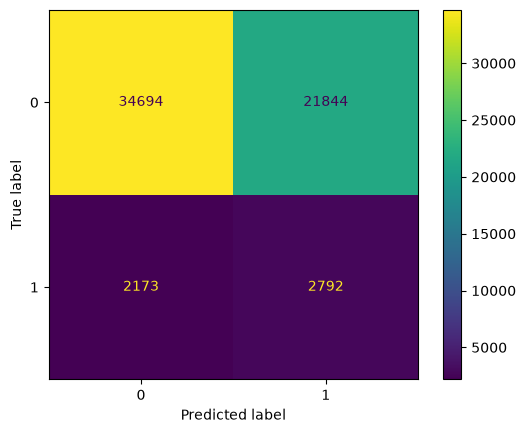

In [12]:
lr_model = build_pipeline(
    LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    )
)

lr_model.fit(X_train, y_train)

evaluate_model(lr_model, X_test, y_test)

## Random Forest

Accuracy : 0.9194
Precision: 0.8889
Recall   : 0.0016
F1 Score : 0.0032
ROC AUC  : 0.7111


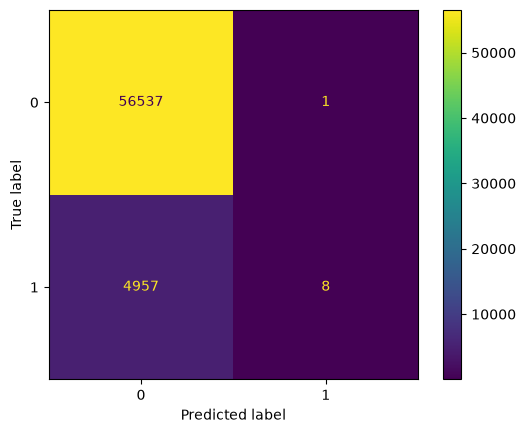

In [13]:
rf_model = build_pipeline(
    RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
)

rf_model.fit(X_train, y_train)

evaluate_model(rf_model, X_test, y_test)

## Cross Validation

Cross-validation evaluates the model on multiple train-validation splits.

This provides a more reliable estimate of performance than a single train-test split.

In [14]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    build_pipeline(
        LogisticRegression(
            random_state=42,
            max_iter=1000,
            class_weight="balanced"
        )
    ),
    X,
    y,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC-AUC Scores:", cv_scores)
print("Average ROC-AUC:", cv_scores.mean())

ROC-AUC Scores: [0.63173492 0.61771842 0.62202893 0.61978284 0.62572047]
Average ROC-AUC: 0.6233971140296892


## Hyperparameter Tuning

Use Randomized Search with cross-validation to find better Random Forest parameters.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

In [16]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10]
}

In [17]:
rf_search = RandomizedSearchCV(
    estimator=build_pipeline(
        RandomForestClassifier(random_state=42, n_jobs=-1)
    ),
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1
)

In [18]:
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_split': [2, 5, ...], 'classifier__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for

In [19]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest ROC-AUC:")
print(rf_search.best_score_)

Best Parameters:
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 10, 'classifier__max_depth': 10}

Best ROC-AUC:
0.732874084316483


Accuracy : 0.9193
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.7380


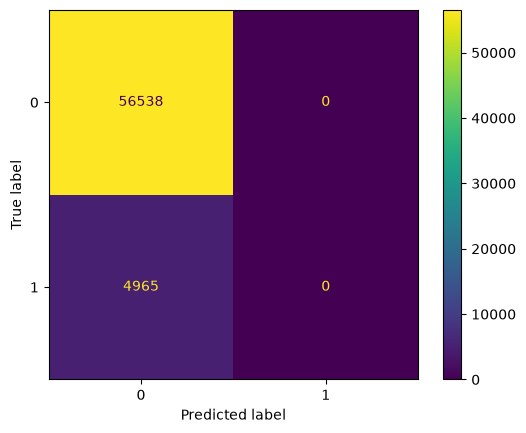

In [21]:
best_rf = rf_search.best_estimator_

evaluate_model(best_rf, X_test, y_test)

## XGBoost

XGBoost (Extreme Gradient Boosting) is an ensemble learning algorithm that builds decision trees sequentially.

Each new tree focuses on correcting the errors made by the previous trees, often achieving higher accuracy than Random Forest on tabular datasets.

In [23]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from xgboost import XGBClassifier

In [25]:
from xgboost import XGBClassifier

In [26]:
xgb_model = build_pipeline(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [27]:
xgb_model = build_pipeline(
    XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
)

In [29]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](129,)","['SK_ID_CURR','NAME_CONTRACT_TYPE','CODE_GENDER',...,'INCOME_PER_FAMILY', 'CREDIT_PER_FAMILY','EMPLOYMENT_AGE_RATIO']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,129
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'dro

Accuracy : 0.9187
Precision: 0.4489
Recall   : 0.0336
F1 Score : 0.0626
ROC AUC  : 0.7509


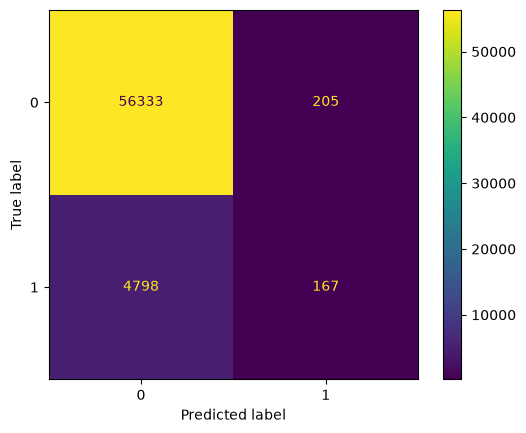

In [30]:
evaluate_model(xgb_model, X_test, y_test)

In [32]:
def compare_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_prob)
        })

    results_df = pd.DataFrame(results)

    return results_df.sort_values(
        by="ROC-AUC",
        ascending=False
    ).reset_index(drop=True)

In [33]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Tuned Random Forest": best_rf,
    "XGBoost": xgb_model
}

In [34]:
comparison_df = compare_models(
    models,
    X_test,
    y_test
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,XGBoost,0.918654,0.448925,0.033635,0.062582,0.750890
1,Tuned Random Forest,0.919272,0.000000,0.000000,0.000000,0.737979
2,Random Forest,0.919386,0.888889,0.001611,0.003217,0.711119
3,Logistic Regression,0.609499,0.113330,0.562336,0.188642,0.618280
